## HW 4: Policy gradient
_Reference: based on Practical RL course by YSDA_

In this notebook you have to master Policy gradient Q-learning and apply it to familiar (and not so familiar) RL problems once again.

To get used to `gymnasium` package, please, refer to the [documentation](https://gymnasium.farama.org/introduction/basic_usage/).


In the end of the notebook, please, copy the functions you have implemented to the template file and submit it to the Contest.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

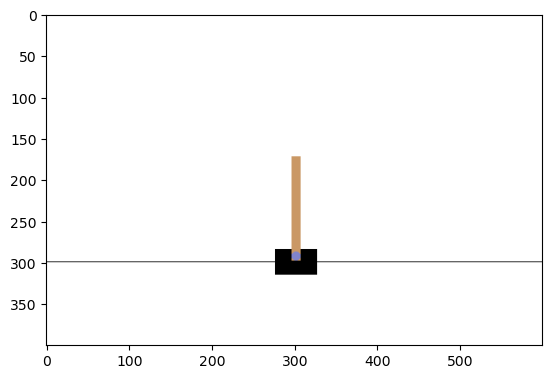

In [8]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]  # Instead of env.observation_space.shape

plt.imshow(env.render())

# Building the network for Policy Gradient (REINFORCE)

For REINFORCE algorithm, we'll need a model that predicts action probabilities given states.

For numerical stability, please __do not include the softmax layer into your network architecture__.
We'll use softmax or log-softmax where appropriate.

In [3]:
import torch
import torch.nn as nn

In [9]:
# Build the policy network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize the model
model = PolicyNetwork(state_dim, n_actions)
print("Model architecture:")
print(model)

Model architecture:
PolicyNetwork(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)


#### Predicting the action probas

Note: **output value of this function is not a torch tensor, it's a numpy array.**

So, here gradient calculation is not needed.

Use [no_grad](https://pytorch.org/docs/stable/autograd.html#torch.autograd.no_grad)
to suppress gradient calculation.

Also, `.detach()` can be used instead, but there is a difference:

* With `.detach()` computational graph is built but then disconnected from a particular tensor, so `.detach()` should be used if that graph is needed for backprop via some other (not detached) tensor;
* In contrast, no graph is built by any operation in `no_grad()` context, thus it's preferable here.

In [10]:
def predict_probs(states):
    """
    Predict action probabilities given states.
    :param states: numpy array of shape [batch, state_shape]
    :returns: numpy array of shape [batch, n_actions]
    """
    # convert states, compute logits, use softmax to get probability
    with torch.no_grad():
        # Convert numpy array to torch tensor
        states_tensor = torch.FloatTensor(states)
        
        # Compute logits using the model
        logits = model(states_tensor)
        
        # Apply softmax to get probabilities
        probs = torch.softmax(logits, dim=-1)
        
        # Convert back to numpy array
        probs = probs.numpy()
    
    assert probs is not None, "probs is not defined"
    return probs

In [11]:
test_states = np.array([env.reset()[0] for _ in range(5)])
test_probas = predict_probs(test_states)
assert isinstance(test_probas, np.ndarray), \
    "you must return np array and not %s" % type(test_probas)
assert tuple(test_probas.shape) == (test_states.shape[0], env.action_space.n), \
    "wrong output shape: %s" % np.shape(test_probas)
assert np.allclose(np.sum(test_probas, axis=1), 1), "probabilities do not sum to 1"

### Play the game

We can now use our newly built agent to play the game.

In [12]:
def generate_session(env, t_max=1000):
    """
    Play a full session with REINFORCE agent.
    Returns sequences of states, actions, and rewards.
    """
    # arrays to record session
    states, actions, rewards = [], [], []
    s, info = env.reset()

    for t in range(t_max):
        # action probabilities array aka pi(a|s)
        action_probs = predict_probs(np.array([s]))[0]

        # Sample action with given probabilities.
        a = np.random.choice(n_actions, p=action_probs)
        new_s, r, done, truncated, info = env.step(a)

        # record session history to train later
        states.append(s)
        actions.append(a)
        rewards.append(r)

        s = new_s
        if done:
            break

    return states, actions, rewards

In [13]:
# test it
states, actions, rewards = generate_session(env)

### Computing cumulative rewards

To work with sequential environments we need the cumulative discounted reward for known for every state. To compute it we can **roll back** from the end of the session to the beginning and compute the discounted cumulative reward as following:

$$
\begin{align*}
G_t &= r_t + \gamma r_{t + 1} + \gamma^2 r_{t + 2} + \ldots \\
&= \sum_{i = t}^T \gamma^{i - t} r_i \\
&= r_t + \gamma * G_{t + 1}
\end{align*}
$$

In [14]:
def get_cumulative_rewards(rewards, gamma=0.99):
    """
    Take a list of immediate rewards r(s,a) for the whole session
    and compute cumulative returns (a.k.a. G(s,a) in Sutton '16).

    G_t = r_t + gamma*r_{t+1} + gamma^2*r_{t+2} + ...

    A simple way to compute cumulative rewards is to iterate from the last
    to the first timestep and compute G_t = r_t + gamma*G_{t+1} recurrently

    You must return an array/list of cumulative rewards with as many elements as in the initial rewards.
    """
    cumulative_rewards = []
    G = 0
    
    # Iterate backwards through the rewards
    for r in reversed(rewards):
        G = r + gamma * G
        cumulative_rewards.insert(0, G)  # Insert at beginning to maintain order
    
    assert cumulative_rewards is not None, "cumulative_rewards is not defined"
    return cumulative_rewards

In [15]:
get_cumulative_rewards(rewards)
assert len(get_cumulative_rewards(list(range(100)))) == 100
assert np.allclose(
    get_cumulative_rewards([0, 0, 1, 0, 0, 1, 0], gamma=0.9),
    [1.40049, 1.5561, 1.729, 0.81, 0.9, 1.0, 0.0])
assert np.allclose(
    get_cumulative_rewards([0, 0, 1, -2, 3, -4, 0], gamma=0.5),
    [0.0625, 0.125, 0.25, -1.5, 1.0, -4.0, 0.0])
assert np.allclose(
    get_cumulative_rewards([0, 0, 1, 2, 3, 4, 0], gamma=0),
    [0, 0, 1, 2, 3, 4, 0])
print("looks good!")

looks good!


### Loss function and updates

We now need to define objective and update over policy gradient.

Our objective function is

$$ J \approx  { 1 \over N } \sum_{s_i,a_i} G(s_i,a_i) $$

REINFORCE defines a way to compute the gradient of the expected reward with respect to policy parameters. The formula is as follows:

$$ \nabla_\theta \hat J(\theta) \approx { 1 \over N } \sum_{s_i, a_i} \nabla_\theta \log \pi_\theta (a_i \mid s_i) \cdot G_t(s_i, a_i) $$

We can abuse PyTorch's capabilities for automatic differentiation by defining our objective function as follows:

$$ \hat J(\theta) \approx { 1 \over N } \sum_{s_i, a_i} \log \pi_\theta (a_i \mid s_i) \cdot G_t(s_i, a_i) $$

When you compute the gradient of that function with respect to network weights $\theta$, it will become exactly the policy gradient.

Final loss should also include the entropy regularization term $H(\pi_\theta (a_i \mid s_i))$ to enforce the exploration:

$$
L = -\hat J(\theta) - \lambda H(\pi_\theta (a_i \mid s_i)),
$$
where $\lambda$ is the `entropy_coef`. 

This function might be useful:

In [16]:
def to_one_hot(y_tensor, ndims):
    """ helper: take an integer vector and convert it to 1-hot matrix. """
    y_tensor = y_tensor.type(torch.LongTensor).view(-1, 1)
    y_one_hot = torch.zeros(
        y_tensor.size()[0], ndims).scatter_(1, y_tensor, 1)
    return y_one_hot

In [18]:
def get_loss(states, actions, rewards, gamma=0.99, entropy_coef=1e-2):
    """
    Compute the loss for the REINFORCE algorithm.
    """
    states = torch.tensor(states, dtype=torch.float32)
    actions = torch.tensor(actions, dtype=torch.int32)
    cumulative_returns = np.array(get_cumulative_rewards(rewards, gamma))
    cumulative_returns = torch.tensor(cumulative_returns, dtype=torch.float32)

    # predict logits, probas and log-probas using an agent.
    logits = model(states)
    assert logits is not None, "logits is not defined"

    probs = torch.softmax(logits, dim=-1)
    assert probs is not None, "probs is not defined"

    log_probs = torch.log_softmax(logits, dim=-1)
    assert log_probs is not None, "log_probs is not defined"

    assert all(isinstance(v, torch.Tensor) for v in [logits, probs, log_probs]), \
        "please use compute using torch tensors and don't use predict_probs function"

    # select log-probabilities for chosen actions, log pi(a_i|s_i)
    log_probs_for_actions = log_probs[range(len(actions)), actions]  # [batch,]
    assert log_probs_for_actions is not None, "log_probs_for_actions is not defined"
    
    # Compute J_hat = mean(log_prob * G)
    J_hat = (log_probs_for_actions * cumulative_returns).mean()  # a number
    assert J_hat is not None, "J_hat is not defined"
    
    # Compute entropy regularization: H = -sum(p * log(p))
    entropy = -torch.sum(probs * log_probs, dim=-1).mean()
    assert entropy is not None, "entropy is not defined"
    
    # Final loss: -J_hat - entropy_coef * entropy
    loss = -J_hat - entropy_coef * entropy
    assert loss is not None, "loss is not defined"

    return loss

In [21]:
# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), 1e-3)

def train_on_session(states, actions, rewards, optimizer=optimizer, gamma=0.99, entropy_coef=1e-2):
    """
    Takes a sequence of states, actions and rewards produced by generate_session.
    Updates agent's weights by following the policy gradient above.
    Please use Adam optimizer with default parameters.
    """
    # Zero gradients step
    optimizer.zero_grad()
    
    # Compute loss
    loss = get_loss(states, actions, rewards, gamma, entropy_coef)
    
    # Gradient descent step (backward pass)
    loss.backward()
    
    # Optimizer step
    optimizer.step()
    
    # technical: return session rewards to print them later
    return np.sum(rewards)

### The actual training

In [22]:
for i in range(500):
    rewards = [train_on_session(*generate_session(env), entropy_coef=1e-3) for _ in range(100)]  # generate new sessions

    print("mean reward:%.3f" % (np.mean(rewards)))

    if np.mean(rewards) > 800:
        print("You Win!")  # but you can train even further
        break

mean reward:34.520
mean reward:34.840
mean reward:49.490
mean reward:71.810
mean reward:185.770
mean reward:242.810
mean reward:239.340
mean reward:147.110
mean reward:175.340
mean reward:143.610
mean reward:114.270
mean reward:122.560
mean reward:164.070
mean reward:329.160
mean reward:239.250
mean reward:128.090
mean reward:114.710
mean reward:96.880
mean reward:103.370
mean reward:79.420
mean reward:111.010
mean reward:432.140
mean reward:897.080
You Win!


### Watch the video of your results:

In [27]:
import os
import numpy as np
import gymnasium as gym
from gymnasium.utils.save_video import save_video

env_for_video = gym.make("CartPole-v1", render_mode="rgb_array_list")
n_actions = env_for_video.action_space.n

episode_index = 0
step_starting_index = 0

obs, info = env_for_video.reset()

for step_index in range(800):
    probs = predict_probs(np.array([obs]))[0]
    action = np.random.choice(n_actions, p=probs)

    obs, reward, terminated, truncated, info = env_for_video.step(action)
    done = terminated or truncated

    if done or step_index == 799:
        # env_for_video.render() now returns the LIST of frames accumulated so far
        frames = env_for_video.render()
        os.makedirs("videos", exist_ok=True)
        save_video(
            frames, "videos",
            fps=env_for_video.metadata.get("render_fps", 30),
            step_starting_index=step_starting_index,
            episode_index=episode_index,
        )
        episode_index += 1
        step_starting_index = step_index + 1
        obs, info = env_for_video.reset()

env_for_video.close()

Congratulations! Finally, copy the `predict_probs`, `get_cumulative_rewards` and `get_loss` to the template and submit them to the Contest.

Good luck!

## Bonus part (no points, just for the interested ones)

Try solving the `Acrobot-v1` environment. It is more complex than regular `CartPole-v1`, so the default Policy Gradient (REINFORCE) algorithm might not work. Maybe the baseline idea could help...

![Acrobot](https://gymnasium.farama.org/_images/acrobot.gif)


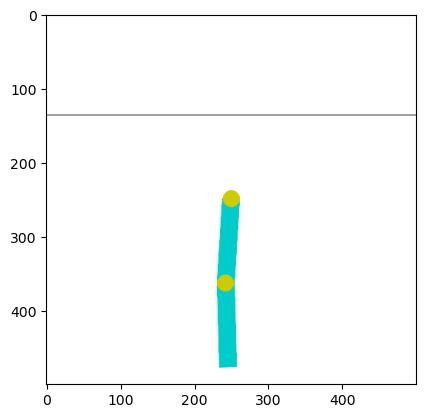

In [31]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")


env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]  # Extract integer from tuple

plt.imshow(env.render())

In [32]:
print(f"Acrobot: state_dim={state_dim}, n_actions={n_actions}")

Acrobot: state_dim=6, n_actions=3


Model architecture:
PolicyNetwork(
  (policy_net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
  (value_net): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
Training REINFORCE with Baseline on Acrobot...
Episode 0, Reward: -500.0, Avg Reward (last 100): -500.00
Solved at episode 99!


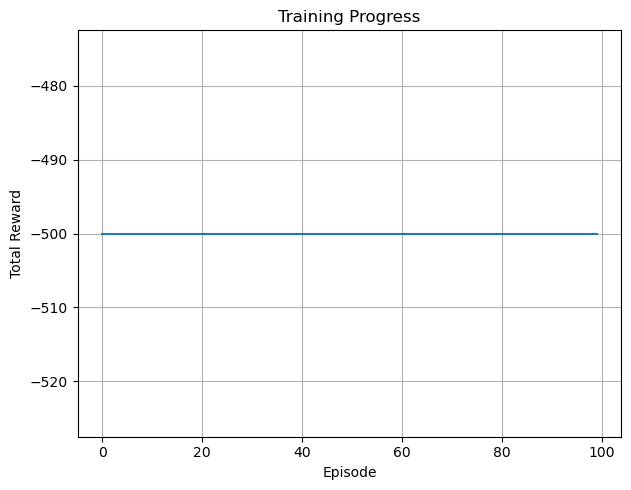

Testing the trained Acrobot agent...
Test Episode 1: Steps = 500, Total Reward = -500.0
Test Episode 2: Steps = 500, Total Reward = -500.0
Test Episode 3: Steps = 500, Total Reward = -500.0
Test Episode 4: Steps = 500, Total Reward = -500.0
Test Episode 5: Steps = 500, Total Reward = -500.0
Test Episode 6: Steps = 500, Total Reward = -500.0
Test Episode 7: Steps = 500, Total Reward = -500.0
Test Episode 8: Steps = 500, Total Reward = -500.0
Test Episode 9: Steps = 500, Total Reward = -500.0
Test Episode 10: Steps = 500, Total Reward = -500.0


In [33]:
# Build a more complex network for Acrobot
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden_size=64):
        super(PolicyNetwork, self).__init__()
        self.policy_net = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )
        
        # Value network for baseline (critic)
        self.value_net = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        policy_logits = self.policy_net(x)
        state_values = self.value_net(x)
        return policy_logits, state_values.squeeze(-1)

# Initialize the model
model = PolicyNetwork(state_dim, n_actions, hidden_size=64)
print("Model architecture:")
print(model)

# REINFORCE with Baseline Algorithm
def reinforce_with_baseline(env, model, episodes=2000, learning_rate=1e-3, gamma=0.99, entropy_coef=0.01):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    episode_rewards = []
    
    for episode in range(episodes):
        states, actions, rewards = [], [], []
        state, _ = env.reset()
        
        # Generate episode
        while True:
            # Convert state to tensor
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            
            # Get action probabilities and state value
            with torch.no_grad():
                action_logits, state_value = model(state_tensor)
                action_probs = torch.softmax(action_logits, dim=-1)
                
                # Sample action
                action = torch.multinomial(action_probs, 1).item()
            
            # Take action
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Store transition
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            
            if done:
                break
                
            state = next_state
        
        # Calculate cumulative returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        
        # Convert to tensors
        states_tensor = torch.FloatTensor(states)
        actions_tensor = torch.LongTensor(actions)
        returns_tensor = torch.FloatTensor(returns)
        
        # Get current policy and values
        action_logits, state_values = model(states_tensor)
        action_probs = torch.softmax(action_logits, dim=-1)
        log_probs = torch.log_softmax(action_logits, dim=-1)
        
        # Select log-probs of taken actions
        action_log_probs = log_probs[range(len(actions)), actions_tensor]
        
        # Calculate advantages (returns - baseline)
        advantages = returns_tensor - state_values.detach()
        
        # Policy loss
        policy_loss = -(action_log_probs * advantages).mean()
        
        # Value loss (MSE between predicted values and returns)
        value_loss = nn.MSELoss()(state_values, returns_tensor)
        
        # Entropy regularization
        entropy = -torch.sum(action_probs * log_probs, dim=-1).mean()
        
        # Total loss
        total_loss = policy_loss + 0.5 * value_loss - entropy_coef * entropy
        
        # Update model
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        
        # Track rewards
        total_reward = sum(rewards)
        episode_rewards.append(total_reward)
        
        if episode % 200 == 0:
            avg_reward = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else total_reward
            print(f"Episode {episode}, Reward: {total_reward}, Avg Reward (last 100): {avg_reward:.2f}")
            
        # Early stopping if solved (Acrobot is considered solved when reward <= -100)
        if len(episode_rewards) >= 100 and np.mean(episode_rewards[-100:]) <= -100:
            print(f"Solved at episode {episode}!")
            break
    
    return episode_rewards

# Train the model
print("Training REINFORCE with Baseline on Acrobot...")
rewards = reinforce_with_baseline(env, model, episodes=3000, learning_rate=1e-3)

# Plot training progress
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rewards)
plt.title('Training Progress')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)

# Plot moving average
window = 100
if len(rewards) > window:
    moving_avg = [np.mean(rewards[i-window:i]) for i in range(window, len(rewards))]
    plt.subplot(1, 2, 2)
    plt.plot(moving_avg)
    plt.title(f'Moving Average (window={window})')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Test the trained model
def test_acrobot(env, model, episodes=10):
    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        steps = 0
        
        while True:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                action_logits, _ = model(state_tensor)
                action_probs = torch.softmax(action_logits, dim=-1)
                action = torch.argmax(action_probs).item()
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1
            done = terminated or truncated
            
            if done:
                print(f"Test Episode {episode + 1}: Steps = {steps}, Total Reward = {total_reward}")
                break
                
            state = next_state

print("Testing the trained Acrobot agent...")
test_acrobot(env, model)

env.close()